# **Project Name**    -  Mental Health in Tech Survey: What Drives Treatment-Seeking & Workplace Support?

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -** Yashwanth

# **Project Summary -**

Mental health is one of the most under-discussed operational risks in the technology industry. Long hours, high pressure and fast-changing teams make tech workers vulnerable to stress, burnout, anxiety and depression, yet stigma keeps many of them silent. This project analyses the 2014 *Mental Health in Tech Survey* run by Open Sourcing Mental Illness (OSMI): 1,259 respondents, 27 questions covering demographics, personal and family history, employer benefits, and attitudes toward disclosing mental and physical health issues.

The data needed careful cleaning before any analysis. Eight ages were impossible (for example -1726, 5 and 99,999,999,999) and were replaced with the median. The free-text Gender field contained roughly 50 different spellings and was standardised into Male, Female and Other. Missing values in self_employed and work_interfere were handled deliberately: work_interfere is only asked of people who have a condition, so blanks were labelled "Not applicable" instead of being imputed. Around 515 rows lack a state because they are outside the USA, and the mostly empty comments column was retained but flagged. No duplicates were found. Feature engineering added age groups, binary flags, a work-interference score and a 0-5 employer support score.

The analysis follows the UBM rule (Univariate, Bivariate, Multivariate) across 26 charts, and every relationship was validated with chi-square tests and Cramer's V so that conclusions rest on statistics rather than visual impression alone.

The key findings are as follows. First, the sample is young, male-dominated and US-centred: the median age is 31, 79% of respondents are male and 60% are from the United States. It is also strongly self-selected, since almost half of all responses arrived on launch day, so results describe survey participants, not all tech workers. Second, half of respondents (50.6%) have sought treatment. Third, family history is the strongest personal driver: 74% of respondents with a family history sought treatment versus 36% without. Women (69%) and non-binary or other respondents report much higher treatment rates than men (45%). Fourth, employer support is patchy and poorly communicated. Only 38% know their employer offers mental health benefits, 65% do not know whether anonymity is protected, and 45% do not know how easy it is to take mental health leave. Small firms are the weakest: only 12% of companies with 1-5 employees offer benefits versus 65% of firms with more than 1,000 staff. Fifth, stigma is significant. Only 3.5% would raise a mental health issue in an interview versus 16% for a physical issue, and 23% expect negative consequences from disclosing a mental health issue versus 5% for a physical one. Sixth, awareness matters: employees who know their care options have a 69% treatment rate compared with about 40% of those who do not. Finally, company size, remote work, tech-company status and self-employment show no statistically significant relationship with treatment.

A methodological caution is included: work interference has the largest statistical association with treatment (V = 0.69), but because it is only answered by respondents with a condition, part of that association is built into the survey design rather than being a true behavioural driver.

The business recommendation is to invest in visibility as much as in benefits: communicate existing options, guarantee anonymity, normalise mental health conversations at manager level, prioritise small and mid-sized companies, and add targeted outreach for high-need groups. These steps can raise early help-seeking, reduce hidden burnout and improve retention and productivity.

# **GitHub Link -**

https://github.com/<your-username>/mental-health-in-tech-eda   *(replace with your repository URL after you push the project)*

# **Problem Statement**

**Technology employees face high pressure, yet many never seek help because of stigma, poor awareness of employer support, or fear of career consequences. Employers currently lack evidence on *who* is most likely to need mental health support, *how well* existing benefits are communicated, and *where* stigma is strongest. This project analyses the OSMI 2014 Mental Health in Tech Survey to answer: which personal, organisational and geographic factors are associated with seeking mental health treatment, and how do employees perceive workplace support and the risk of disclosure?**

#### **Define Your Business Objective?**

Help technology employers (HR, People & Culture and leadership teams) design **targeted, cost-effective mental health programmes** by (1) identifying the groups and situations most associated with treatment-seeking, (2) measuring gaps in benefits awareness, anonymity and leave policies, and (3) quantifying stigma around disclosure. The end goal is earlier help-seeking, lower burnout and absenteeism, and higher retention and productivity.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. *(This notebook is written to run top-to-bottom in one go, with input validation and try/except around data loading.)*
3.   Each and every logic has proper comments.
4.   For every chart: *Why this chart? What insight? Business impact / negative-growth signals?*
5.   At least 20 logical & meaningful charts following the **UBM** rule: **U**nivariate → **B**ivariate → **M**ultivariate.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [40]:
# Import Libraries
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency   # statistical validation of relationships

warnings.filterwarnings("ignore")           # keep the notebook output clean
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

### Dataset Loading

In [2]:
# Load Dataset (robust: works locally, on Colab, or with the file in a data/ folder)
CANDIDATE_PATHS = ["survey.csv", "data/survey.csv", "/content/survey.csv"]
DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)

if DATA_PATH is None:
    try:                                        # Google Colab fallback: ask the user to upload
        from google.colab import files
        DATA_PATH = list(files.upload().keys())[0]
    except ImportError:
        raise FileNotFoundError("survey.csv not found. Place it next to this notebook.")

try:
    raw = pd.read_csv(DATA_PATH)
    print(f"Loaded '{DATA_PATH}' successfully.")
except Exception as e:                          # corrupted / unreadable file
    raise RuntimeError(f"Could not read the dataset: {e}")

# Keep an untouched copy of the raw data; all cleaning happens on `df`
df = raw.copy()

Saving survey (1).csv to survey (1).csv
Loaded 'survey (1).csv' successfully.


### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")

Rows: 1259  |  Columns: 27


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing = df.isnull().sum()
missing_df = pd.DataFrame({"missing": missing, "percent": (missing / len(df) * 100).round(1)})
missing_df[missing_df.missing > 0].sort_values("missing", ascending=False)

,missing,percent
comments,1095,87.0
state,515,40.9
work_interfere,264,21.0
self_employed,18,1.4


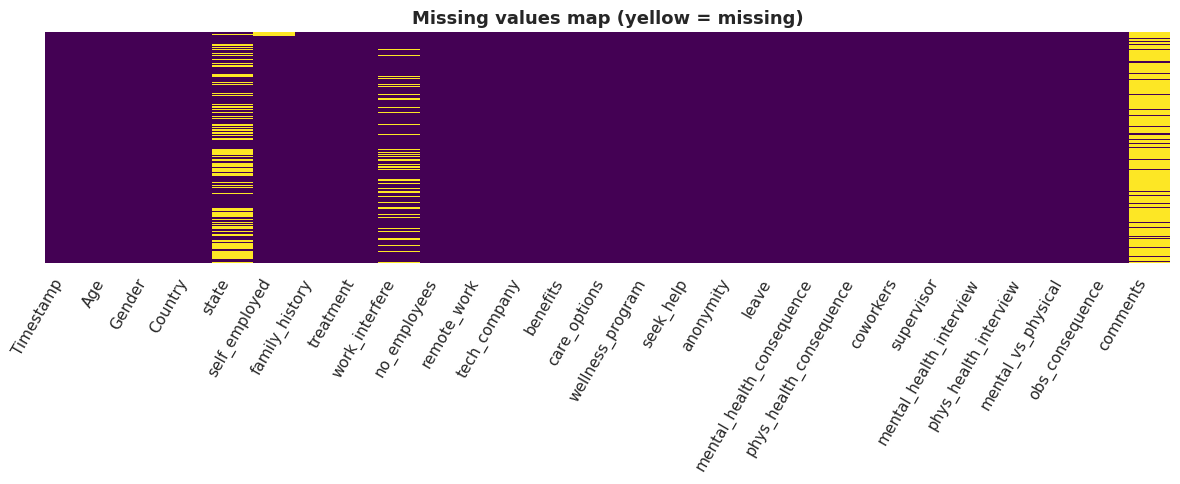

In [8]:
# Visualizing the missing values
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Missing values map (yellow = missing)", fontsize=13, fontweight="bold")
plt.xticks(rotation=60, ha="right")
plt.tight_layout(); plt.show()

### What did you know about your dataset?

The dataset has **1,259 rows and 27 columns** from the 2014 OSMI Mental Health in Tech survey and contains **no duplicate rows**. Almost every column is categorical (Yes / No / Don't know style answers); only `Age` is numeric and `Timestamp` is a date.

Missing values exist in four columns: `comments` (87% empty, free text), `state` (41% empty, because only US respondents are asked), `work_interfere` (21% empty, only asked if the person has a condition) and `self_employed` (1.4%). These are *structural* missing values, not random errors, so they need business-aware handling instead of blind imputation.

Data-quality problems found: impossible ages (negative values, 5, 329, 99,999,999,999) and a free-text `Gender` column with about 50 distinct spellings, which are fixed in Data Wrangling.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
print(list(df.columns))

['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments']


In [10]:
# Dataset Describe
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1259,1246,2014-08-27 12:31:41,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1259.0,NaN,NaN,NaN,79428148.311358,2818299442.981952,-1726.0,27.0,31.0,36.0,99999999999.0
Gender,1259,49,Male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1259,48,United States,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,744,45,CA,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1241,2,No,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1259,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1259,2,Yes,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,995,4,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1259,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

| Group | Variables | Meaning |
|---|---|---|
| Demographics | `Timestamp`, `Age`, `Gender`, `Country`, `state` | When and who answered; state is US-only |
| Employment | `self_employed`, `no_employees`, `remote_work`, `tech_company` | Type and size of the employer |
| Personal health | `family_history`, `treatment` (**target**), `work_interfere` | Family history, whether treatment was sought, and interference with work |
| Employer support | `benefits`, `care_options`, `wellness_program`, `seek_help`, `anonymity`, `leave` | Benefits offered, awareness, resources, anonymity, ease of medical leave |
| Attitudes / stigma | `mental_health_consequence`, `phys_health_consequence`, `coworkers`, `supervisor`, `mental_health_interview`, `phys_health_interview`, `mental_vs_physical`, `obs_consequence` | Fear of consequences and willingness to disclose |
| Free text | `comments` | Optional notes |

**Target variable used throughout the analysis: `treatment`** (Have you sought treatment for a mental health condition?).

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    n = df[col].nunique()
    if n <= 12:
        print(f"{col:28s} ({n:>3} unique): {sorted(df[col].dropna().astype(str).unique())}")
    else:
        print(f"{col:28s} ({n:>3} unique): e.g. {list(df[col].dropna().astype(str).unique()[:5])} ...")

Timestamp                    (1246 unique): e.g. ['2014-08-27 11:29:31', '2014-08-27 11:29:37', '2014-08-27 11:29:44', '2014-08-27 11:29:46', '2014-08-27 11:30:22'] ...
Age                          ( 53 unique): e.g. ['37', '44', '32', '31', '33'] ...
Gender                       ( 49 unique): e.g. ['Female', 'M', 'Male', 'male', 'female'] ...
Country                      ( 48 unique): e.g. ['United States', 'Canada', 'United Kingdom', 'Bulgaria', 'France'] ...
state                        ( 45 unique): e.g. ['IL', 'IN', 'TX', 'TN', 'MI'] ...
self_employed                (  2 unique): ['No', 'Yes']
family_history               (  2 unique): ['No', 'Yes']
treatment                    (  2 unique): ['No', 'Yes']
work_interfere               (  4 unique): ['Never', 'Often', 'Rarely', 'Sometimes']
no_employees                 (  6 unique): ['1-5', '100-500', '26-100', '500-1000', '6-25', 'More than 1000']
remote_work                  (  2 unique): ['No', 'Yes']
tech_company                

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# ---- 1. Timestamp -> proper datetime --------------------------------------------------
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

# ---- 2. Standardise the ~50 free-text Gender spellings into 3 groups -------------------
MALE = {"male","m","male-ish","maile","mal","male (cis)","make","man","msle","mail","malr",
        "cis male","cis man","guy (-ish) ^_^","ostensibly male, unsure what that really means",
        "something kinda male?"}
FEMALE = {"female","f","woman","femake","cis female","female (cis)","cis-female/femme","femail",
          "female (trans)","trans-female","trans woman"}

def clean_gender(value):
    """Map a raw gender string to Male / Female / Other (case & whitespace insensitive)."""
    v = str(value).strip().lower()
    if v in MALE:   return "Male"
    if v in FEMALE: return "Female"
    return "Other"                      # non-binary, genderqueer, agender, unclear entries...

df["Gender"] = df["Gender"].apply(clean_gender)

# ---- 3. Fix impossible ages (negative, <18, >75, 99999999999 ...) -> median ------------
bad_age = (df["Age"] < 18) | (df["Age"] > 75)
print(f"Invalid ages found: {bad_age.sum()} -> {sorted(df.loc[bad_age, 'Age'].tolist())}")
df.loc[bad_age, "Age"] = np.nan
df["Age"] = df["Age"].fillna(df["Age"].median()).astype(int)

# ---- 4. Structural missing values: fill with meaningful labels, NOT statistics ---------
df["self_employed"]   = df["self_employed"].fillna("No")              # 1.4% blank; majority class
df["work_interfere"]  = df["work_interfere"].fillna("Not applicable") # only asked if a condition exists
df["state"]           = df["state"].fillna("Non-US")                  # state is US-only
df["comments"]        = df["comments"].fillna("No comment")

# ---- 5. Feature engineering ---------------------------------------------------------
df["age_group"] = pd.cut(df["Age"], bins=[17, 24, 34, 44, 54, 75],
                         labels=["18-24", "25-34", "35-44", "45-54", "55+"])

df["treatment_bin"]         = (df["treatment"] == "Yes").astype(int)          # target as 0/1
df["family_history_bin"]    = (df["family_history"] == "Yes").astype(int)
df["is_female"]             = (df["Gender"] == "Female").astype(int)
df["remote_bin"]            = (df["remote_work"] == "Yes").astype(int)
df["tech_bin"]              = (df["tech_company"] == "Yes").astype(int)
df["obs_bin"]               = (df["obs_consequence"] == "Yes").astype(int)
df["mh_consequence_bin"]    = (df["mental_health_consequence"] == "Yes").astype(int)

# Ordinal score for how much work is affected (NaN when not applicable)
df["work_interfere_score"] = df["work_interfere"].map({"Never": 0, "Rarely": 1, "Sometimes": 2, "Often": 3})

# Employer support score 0-5: number of support features the employee CONFIRMS exist
SUPPORT_COLS = ["benefits", "care_options", "wellness_program", "seek_help", "anonymity"]
df["support_score"] = sum((df[c] == "Yes").astype(int) for c in SUPPORT_COLS)

# ---- 6. Validation checks (fail loudly if cleaning went wrong) ------------------------
assert df["Age"].between(18, 75).all(),         "Age still contains invalid values"
assert set(df["Gender"].unique()) == {"Male", "Female", "Other"}
assert df[["Age", "Gender", "treatment", "self_employed"]].isnull().sum().sum() == 0
print("Cleaning checks passed.  Shape:", df.shape)
print(df["Gender"].value_counts().to_dict())
df.head()

Invalid ages found: 8 -> [-1726, -29, -1, 5, 8, 11, 329, 99999999999]
Cleaning checks passed.  Shape: (1259, 37)
{'Male': 994, 'Female': 251, 'Other': 14}


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments,age_group,treatment_bin,family_history_bin,is_female,remote_bin,tech_bin,obs_bin,mh_consequence_bin,work_interfere_score,support_score
0,2014-08-27 11:29:31,37,Female,United States,IL,No,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,No comment,35-44,1,0,1,0,1,0,0,3.0,3
1,2014-08-27 11:29:37,44,Male,United States,IN,No,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,No comment,35-44,0,0,0,0,0,0,0,1.0,0
2,2014-08-27 11:29:44,32,Male,Canada,Non-US,No,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,No comment,25-34,0,0,0,0,1,0,0,1.0,0
3,2014-08-27 11:29:46,31,Male,United Kingdom,Non-US,No,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,No comment,25-34,1,1,0,0,1,1,1,3.0,1
4,2014-08-27 11:30:22,31,Male,United States,TX,No,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,No comment,25-34,0,0,0,1,1,0,0,0.0,1


### What all manipulations have you done and insights you found?

**Manipulations**
1. Converted `Timestamp` to datetime.
2. **Gender:** collapsed ~50 spellings (`M`, `maile`, `Cis Man`, `femail`, `Trans woman`, ...) into **Male (994), Female (251), Other (14)**.
3. **Age:** 8 impossible values (e.g. -1726, 5, 329, 99999999999) were set to the median (31) so they no longer distort averages.
4. **Missing values:** `work_interfere` -> "Not applicable", `state` -> "Non-US", `self_employed` -> "No", `comments` -> "No comment". These blanks carry meaning (skipped questions), so imputing with statistics would have created false information.
5. **Feature engineering:** `age_group`, binary flags for the main questions, `work_interfere_score` (0-3) and a 0-5 `support_score` measuring confirmed employer support.
6. Added assertions so the notebook fails immediately if any cleaning step breaks.

**Insights:** the data is clean enough for analysis but heavily skewed (79% male, 60% US), and missingness is structural, so the analysis focuses on *rates within groups* rather than raw counts.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

Helper functions are defined once so every chart follows the same, well-commented pattern.

In [13]:
# ---------- Reusable plotting helpers ----------
PAL = {"Yes": "#2a9d8f", "No": "#e76f51", "Maybe": "#f4a261", "Don't know": "#adb5bd",
       "Not sure": "#f4a261", "Some of them": "#e9c46a"}
OVERALL = df["treatment_bin"].mean() * 100                       # baseline treatment rate (%)
SIZE_ORDER = ["1-5", "6-25", "26-100", "100-500", "500-1000", "More than 1000"]

def add_bar_labels(ax, fmt="{:.0f}", suffix=""):
    """Write the value on top of every bar."""
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h) and h > 0:
            ax.annotate(fmt.format(h) + suffix, (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=9, xytext=(0, 2), textcoords="offset points")

def rate_table(data, col, order=None, min_n=1):
    """% of respondents who sought treatment, per category of `col` (with group size n)."""
    g = data.groupby(col, observed=True)["treatment_bin"].agg(n="size", rate=lambda s: s.mean() * 100)
    g = g[g["n"] >= min_n]
    if order is not None:
        g = g.reindex([o for o in order if o in g.index])
    return g

def plot_rate(g, title, xlabel, horizontal=False, figsize=(9, 5), color="#457b9d"):
    """Bar chart of treatment rate per group, with n labels and the overall baseline line."""
    fig, ax = plt.subplots(figsize=figsize)
    labels = [str(i) for i in g.index]
    if horizontal:
        bars = ax.barh(labels, g["rate"], color=color)
        ax.axvline(OVERALL, color="grey", ls="--", label=f"Overall {OVERALL:.1f}%")
        for b, (r, n) in zip(bars, zip(g["rate"], g["n"])):
            ax.text(r + 1, b.get_y() + b.get_height() / 2, f"{r:.0f}%  (n={n})", va="center", fontsize=9)
        ax.set_xlim(0, 110); ax.set_xlabel("% who sought treatment"); ax.set_ylabel(xlabel)
    else:
        bars = ax.bar(labels, g["rate"], color=color)
        ax.axhline(OVERALL, color="grey", ls="--", label=f"Overall {OVERALL:.1f}%")
        for b, (r, n) in zip(bars, zip(g["rate"], g["n"])):
            ax.text(b.get_x() + b.get_width() / 2, r + 1, f"{r:.0f}%\n(n={n})", ha="center", fontsize=9)
        ax.set_ylim(0, 105); ax.set_ylabel("% who sought treatment"); ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=13, fontweight="bold"); ax.legend()
    plt.tight_layout(); plt.show()

def stacked_pct(ct, title, xlabel, figsize=(9, 5), horizontal=False):
    """100% stacked bar from a row-normalised crosstab."""
    colors = [PAL.get(c, "#6c757d") for c in ct.columns]
    ct.plot(kind="barh" if horizontal else "bar", stacked=True, figsize=figsize, color=colors, edgecolor="white")
    plt.title(title, fontsize=13, fontweight="bold"); plt.xlabel("% of respondents" if horizontal else xlabel)
    plt.ylabel(xlabel if horizontal else "% of respondents")
    plt.legend(title="", bbox_to_anchor=(1.01, 1), loc="upper left"); plt.xticks(rotation=0)
    plt.tight_layout(); plt.show()

### **A. Univariate Analysis (Charts 1-8)**

#### Chart - 1 - Target variable: Treatment sought (Donut)

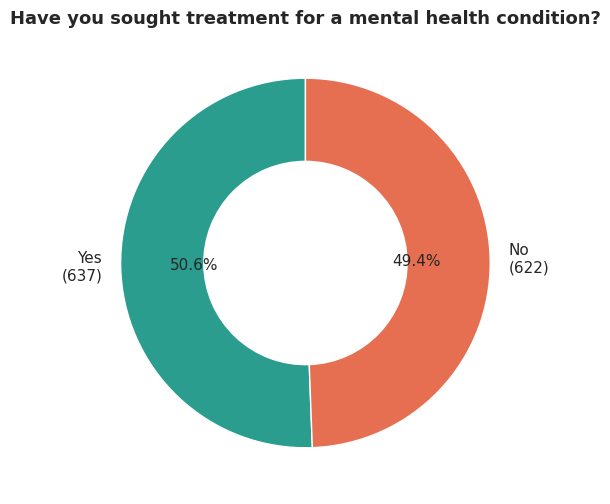

In [14]:
# Chart - 1 visualization code
counts = df["treatment"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=[f"{i}\n({v})" for i, v in counts.items()], autopct="%1.1f%%", startangle=90,
        colors=[PAL[i] for i in counts.index], wedgeprops=dict(width=0.45, edgecolor="white"),
        textprops={"fontsize": 11})
plt.title("Have you sought treatment for a mental health condition?", fontsize=13, fontweight="bold")
plt.show()

##### 1. Why did you pick the specific chart?

A donut chart is the clearest way to show the share of a binary target and to check for class imbalance before any deeper analysis.

##### 2. What is/are the insight(s) found from the chart?

**50.6% (637)** of respondents have sought treatment and **49.4% (622)** have not. The target is almost perfectly balanced, so no resampling is needed and simple rates are meaningful comparisons.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** half of this workforce sample is already engaging with mental health care, which shows real demand for employer-supported services and a strong business case for benefits. **Caution:** the survey was voluntary and topic-focused, so people with lived experience were probably more likely to respond; the true rate across all tech workers is likely lower.

#### Chart - 2 - Age distribution (Histogram + KDE)

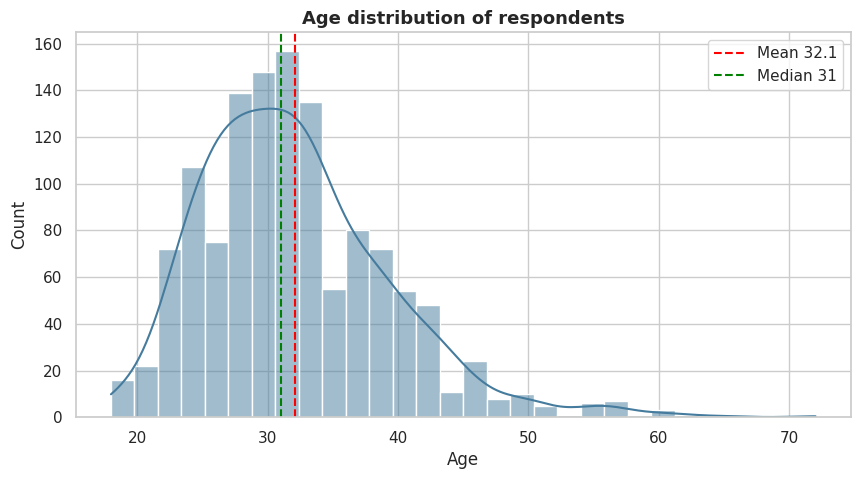

count    1259.0
mean       32.1
std         7.3
min        18.0
25%        27.0
50%        31.0
75%        36.0
max        72.0
Name: Age, dtype: float64


In [15]:
# Chart - 2 visualization code
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["Age"], bins=30, kde=True, color="#457b9d", ax=ax)
ax.axvline(df["Age"].mean(),   color="red",   ls="--", label=f"Mean {df['Age'].mean():.1f}")
ax.axvline(df["Age"].median(), color="green", ls="--", label=f"Median {df['Age'].median():.0f}")
ax.set_title("Age distribution of respondents", fontsize=13, fontweight="bold"); ax.legend()
plt.show()
print(df["Age"].describe().round(1))

##### 1. Why did you pick the specific chart?

A histogram with a KDE curve shows the shape, centre and spread of a numeric variable, and reveals skew and outliers in one view.

##### 2. What is/are the insight(s) found from the chart?

Ages are **right-skewed**: mean 32.1 and median 31, with the middle 50% between 27 and 36. **25-34 year-olds make up 57%** of the sample, while only 17 people are 55 or older. The cleaned range is 18-72.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the sample matches the core early-to-mid-career tech workforce, so findings apply to the majority of employees. **Negative growth risk:** older staff are almost invisible in the data (1.4%), so programmes designed from this data may overlook their needs; employers should collect additional feedback from senior employees.

#### Chart - 3 - Gender distribution (Countplot)

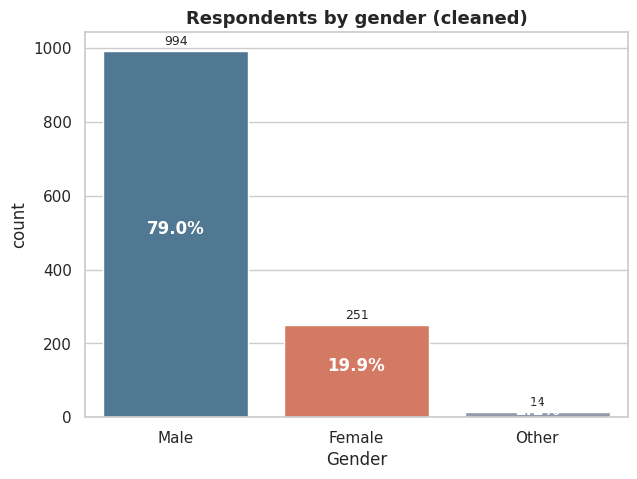

In [16]:
# Chart - 3 visualization code
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x="Gender", order=["Male", "Female", "Other"], palette=["#457b9d", "#e76f51", "#8d99ae"], ax=ax)
add_bar_labels(ax)
for p, cnt in zip(ax.patches, df["Gender"].value_counts()[["Male", "Female", "Other"]]):
    ax.annotate(f"{cnt / len(df) * 100:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height() / 2), ha="center", color="white", fontweight="bold")
ax.set_title("Respondents by gender (cleaned)", fontsize=13, fontweight="bold")
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is the standard choice for a categorical variable with few levels; it shows absolute counts, and percentages are added for context.

##### 2. What is/are the insight(s) found from the chart?

**Male 994 (79.0%)**, **Female 251 (19.9%)**, **Other 14 (1.1%)**. The sample is strongly male, consistent with the well-documented gender imbalance in the tech industry.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the split mirrors industry demographics, so the findings are representative of who works in tech. **Caution:** conclusions about women and especially the 'Other' group (n=14) rest on small samples and should be treated as directional; companies should run their own inclusive surveys before designing group-specific programmes.

#### Chart - 4 - Top 10 countries (Horizontal countplot)

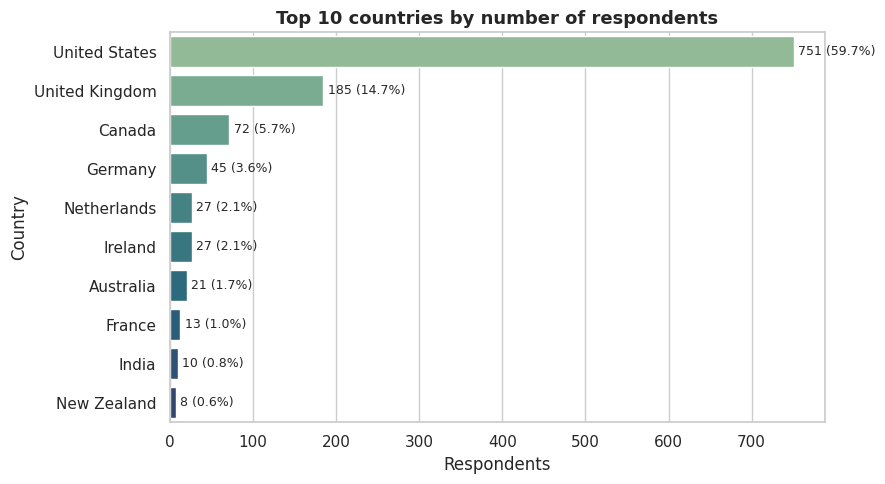

Top-10 countries cover 92.1% of all respondents


In [17]:
# Chart - 4 visualization code
top10 = df["Country"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top10.values, y=top10.index, palette="crest", ax=ax)
for i, v in enumerate(top10.values):
    ax.text(v + 5, i, f"{v} ({v / len(df) * 100:.1f}%)", va="center", fontsize=9)
ax.set_title("Top 10 countries by number of respondents", fontsize=13, fontweight="bold"); ax.set_xlabel("Respondents")
plt.tight_layout(); plt.show()
print(f"Top-10 countries cover {top10.sum() / len(df) * 100:.1f}% of all respondents")

##### 1. Why did you pick the specific chart?

With 48 countries, a sorted horizontal bar of the top 10 is far more readable than a full column chart, and long country names fit on the y-axis.

##### 2. What is/are the insight(s) found from the chart?

The **United States (751, 59.6%)**, **United Kingdom (185, 14.7%)** and **Canada (72, 5.7%)** dominate; the top 10 countries cover **92%** of the data. Most other countries have too few responses for reliable comparison.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the US, UK and Canada have enough data for reliable country-level comparison (used in Chart 15). **Negative:** the results are Western-centric; expanding to Asia, Africa and Latin America would need new data collection because cultural stigma around mental health differs strongly across regions.

#### Chart - 5 - Company size (Countplot)

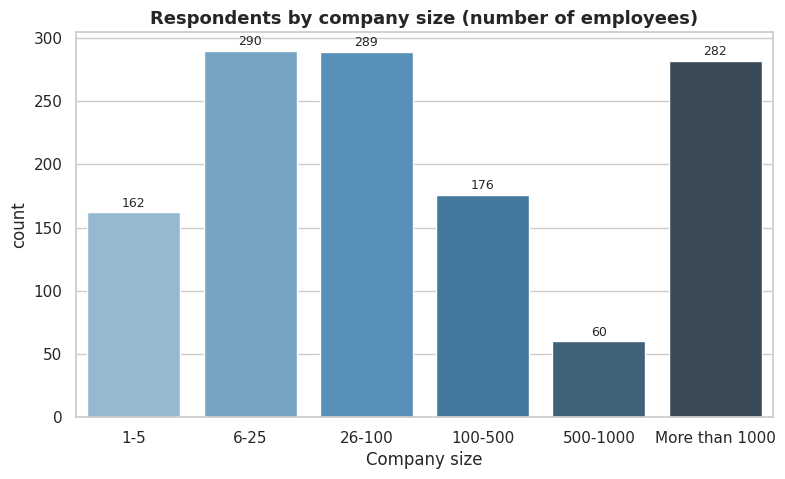

In [18]:
# Chart - 5 visualization code
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x="no_employees", order=SIZE_ORDER, palette="Blues_d", ax=ax)
add_bar_labels(ax)
ax.set_title("Respondents by company size (number of employees)", fontsize=13, fontweight="bold")
ax.set_xlabel("Company size"); plt.show()

##### 1. Why did you pick the specific chart?

An ordered count plot keeps the natural small-to-large order of company sizes and reveals which segments are well represented.

##### 2. What is/are the insight(s) found from the chart?

Respondents are spread across sizes: **6-25 (290)**, **26-100 (289)** and **1000+ (282)** are the largest groups, while **500-1000 is the smallest (60)**. Both start-ups and large enterprises are well represented.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the balanced spread allows a fair comparison of support by company size (Chart 17). **Insight for growth:** the large share of small-company employees (about 59% work in firms with fewer than 100 people) means low-cost, scalable solutions such as EAP partnerships are important for this population.

#### Chart - 6 - Work interference (Countplot)

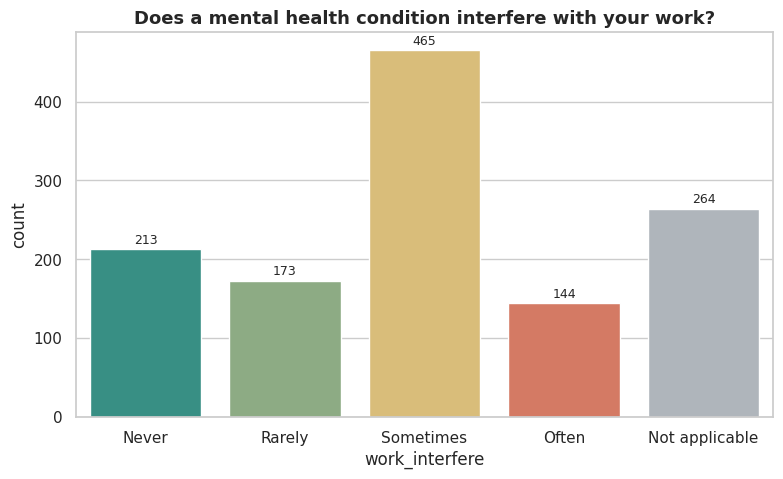

Among 995 who answered: at least 'Sometimes' = 61.2%


In [19]:
# Chart - 6 visualization code
order = ["Never", "Rarely", "Sometimes", "Often", "Not applicable"]
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x="work_interfere", order=order, palette=["#2a9d8f", "#8ab17d", "#e9c46a", "#e76f51", "#adb5bd"], ax=ax)
add_bar_labels(ax)
ax.set_title("Does a mental health condition interfere with your work?", fontsize=13, fontweight="bold")
plt.show()
answered = df[df["work_interfere"] != "Not applicable"]
print(f"Among {len(answered)} who answered: at least 'Sometimes' = {answered['work_interfere'].isin(['Sometimes','Often']).mean() * 100:.1f}%")

##### 1. Why did you pick the specific chart?

An ordered count plot for an ordinal scale (Never to Often) shows how intensity is distributed; 'Not applicable' is kept separate because it represents respondents who skipped the question.

##### 2. What is/are the insight(s) found from the chart?

**Sometimes (465)** is the most common answer and **Often (144)** is 11% of everyone. Of the **995** people who answered, **61%** say their condition interferes with work at least sometimes. 264 people (21%) skipped the question.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Negative growth signal:** a productivity impact is common. Roughly six in ten affected employees report work interference, which translates into lost output, errors and absenteeism. **Positive:** this quantifies the cost of doing nothing and supports the ROI case for early-intervention programmes.

#### Chart - 7 - Employer support features (100% stacked horizontal bars)

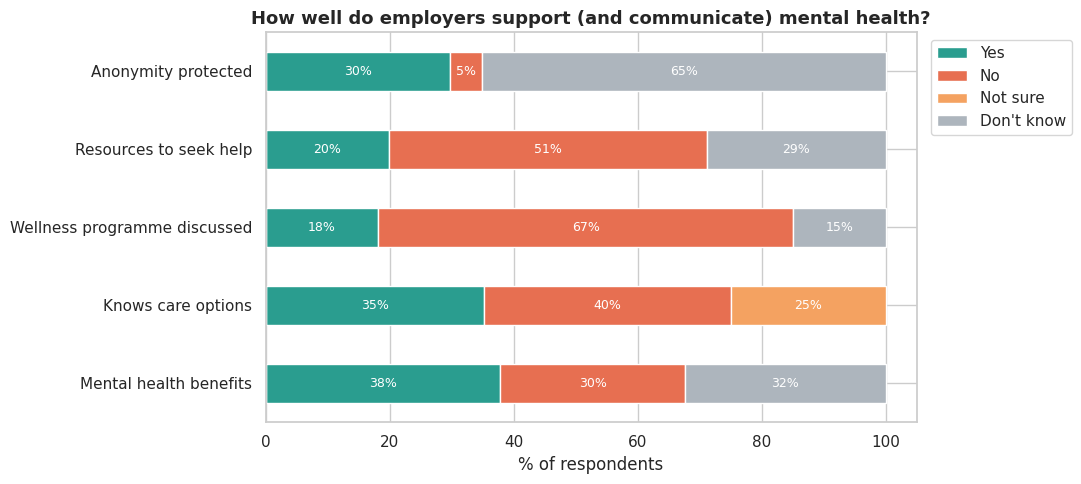

In [20]:
# Chart - 7 visualization code
labels = {"benefits": "Mental health benefits", "care_options": "Knows care options", "wellness_program": "Wellness programme discussed",
          "seek_help": "Resources to seek help", "anonymity": "Anonymity protected"}
tbl = pd.DataFrame({labels[c]: df[c].value_counts(normalize=True) * 100 for c in SUPPORT_COLS}).T.fillna(0)
tbl = tbl[[c for c in ["Yes", "No", "Not sure", "Don't know"] if c in tbl.columns]]
ax = tbl.plot(kind="barh", stacked=True, figsize=(11, 5), color=[PAL[c] for c in tbl.columns], edgecolor="white")
for cont in ax.containers:   # hide labels on tiny/empty segments to avoid clutter
    ax.bar_label(cont, labels=[f"{v:.0f}%" if v >= 3 else "" for v in cont.datavalues], label_type="center", fontsize=9, color="white")
ax.set_title("How well do employers support (and communicate) mental health?", fontsize=13, fontweight="bold")
ax.set_xlabel("% of respondents"); ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

A 100% stacked horizontal bar lets me compare the answer mix of five related support questions side by side on the same scale.

##### 2. What is/are the insight(s) found from the chart?

Support is thin and poorly communicated: only **38%** confirm mental health benefits, **35%** know their care options, **20%** say resources exist, and just **18%** say wellness programmes were discussed. On anonymity, **65% answer 'Don't know'** and only **30%** are sure it is protected.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Negative growth:** the large 'Don't know' segments are a communication failure; even where benefits exist, employees cannot rely on them. **Positive opportunity:** the cheapest improvement is to publicise existing benefits and guarantee confidentiality clearly, which can raise utilisation without new spending.

#### Chart - 8 - Survey response timeline (Bar chart, first 15 days)

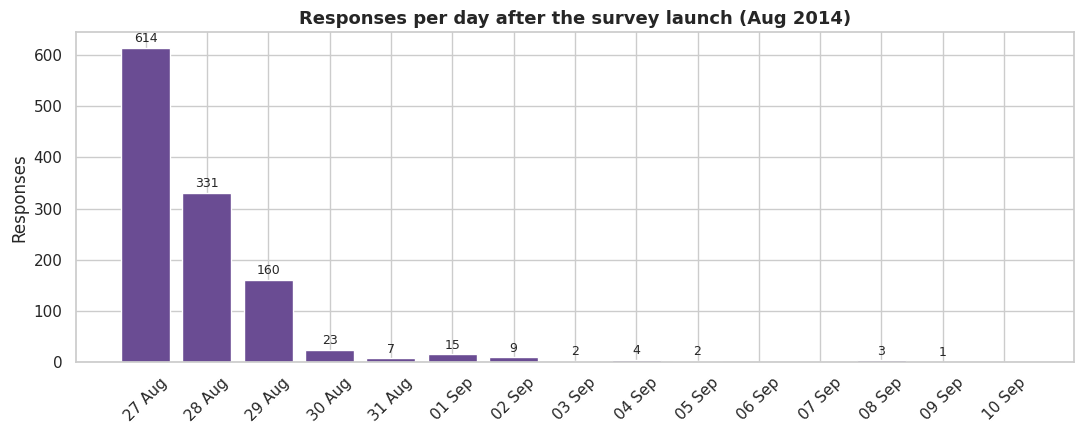

Launch day share: 48.8%   |  August 2014 share: 90.2%


In [21]:
# Chart - 8 visualization code
daily = df.set_index("Timestamp").resample("D").size()["2014-08-27":"2014-09-10"]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(daily.index.strftime("%d %b"), daily.values, color="#6a4c93")
add_bar_labels(ax)
ax.set_title("Responses per day after the survey launch (Aug 2014)", fontsize=13, fontweight="bold")
ax.set_ylabel("Responses"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print(f"Launch day share: {daily.iloc[0] / len(df) * 100:.1f}%   |  August 2014 share: {(df['Timestamp'].dt.to_period('M') == '2014-08').mean() * 100:.1f}%")

##### 1. Why did you pick the specific chart?

A time-based bar chart is the simplest way to see how data collection unfolded and to detect sampling patterns that could bias the results.

##### 2. What is/are the insight(s) found from the chart?

**614 responses (49%) arrived on launch day (27 Aug 2014)** and **90% within August 2014**, followed by a sharp decay. This pattern indicates a viral, self-selected online sample rather than a random survey.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Caution / negative-growth risk:** self-selection bias means people already interested in mental health were more likely to answer, so any absolute percentage (for example 50.6% treated) should not be generalised to all tech workers. **Positive:** relative comparisons between groups remain valid, which is what the rest of this analysis relies on.

### **B. Bivariate Analysis (Charts 9-23)**

*Categorical vs Categorical (9-18), Numerical vs Categorical (19-22) and a statistical ranking of predictors (23).*

#### Chart - 9 - Treatment rate by Gender (Bar)

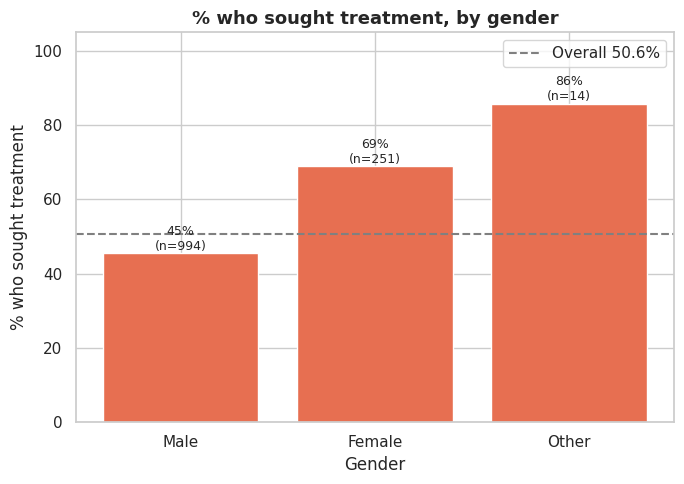

In [22]:
# Chart - 9 visualization code
g = rate_table(df, "Gender", order=["Male", "Female", "Other"])
plot_rate(g, "% who sought treatment, by gender", "Gender", figsize=(7, 5), color="#e76f51")

##### 1. Why did you pick the specific chart?

Because the groups have very different sizes, a *rate* bar chart (with n printed) is fairer than counts and lets me compare against the overall baseline.

##### 2. What is/are the insight(s) found from the chart?

**Women: 69%**, **Male: 45%**, **Other: 86% (n=14 only)** versus 50.6% overall. Women are about 1.5x more likely than men to have sought treatment. Part of this gap is explained by family history (53% of women report it vs 35% of men).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** women and gender-diverse staff are clearly engaging with care, so tailored, inclusive support and gender-neutral wording in benefits will resonate. **Negative growth signal:** the much lower male rate (45%) may reflect under-treatment caused by stigma; men are the majority of the workforce, so engaging them has the largest total impact.

#### Chart - 10 - Family history vs Treatment (Grouped countplot)

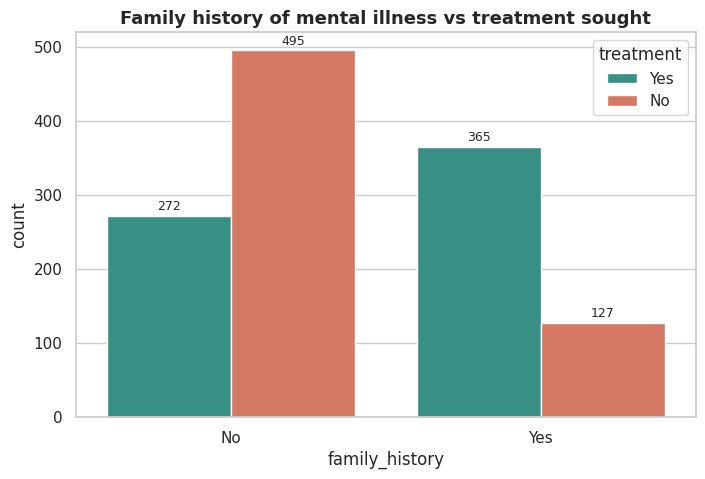

family_history
No     35.5
Yes    74.2


In [23]:
# Chart - 10 visualization code
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="family_history", hue="treatment", hue_order=["Yes", "No"], palette=PAL, ax=ax)
add_bar_labels(ax)
ax.set_title("Family history of mental illness vs treatment sought", fontsize=13, fontweight="bold")
plt.show()
print((df.groupby("family_history")["treatment_bin"].mean() * 100).round(1).to_string())

##### 1. Why did you pick the specific chart?

A grouped count plot shows both the size of each group and the split within it, making the strength of the relationship visible at a glance.

##### 2. What is/are the insight(s) found from the chart?

**74% of respondents with a family history sought treatment versus 36% without**, a gap of about 2x. Family history is the strongest *personal* factor in the dataset (Cramer's V = 0.38, p < 0.001).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** family history is a legitimate, non-invasive signal for outreach: wellness campaigns can invite employees who care for or grew up with affected relatives. **Negative:** the 36% treatment rate among people *without* family history hints at people who need help but are not getting it; screening should not rely on family history alone.

#### Chart - 11 - Employer benefits vs Treatment (Bar)

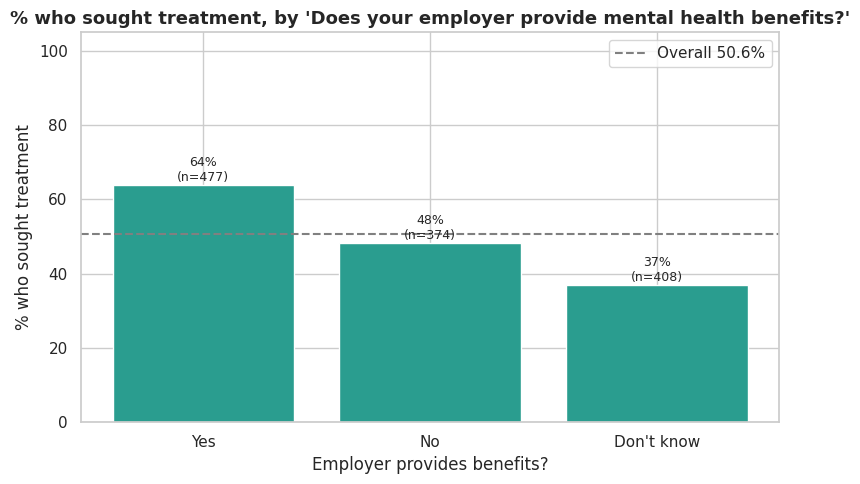

In [24]:
# Chart - 11 visualization code
g = rate_table(df, "benefits", order=["Yes", "No", "Don't know"])
plot_rate(g, "% who sought treatment, by 'Does your employer provide mental health benefits?'", "Employer provides benefits?", figsize=(8, 5), color="#2a9d8f")

##### 1. Why did you pick the specific chart?

A rate bar chart makes it easy to compare treatment-seeking across the three benefit answers and check whether benefits relate to help-seeking.

##### 2. What is/are the insight(s) found from the chart?

Employees with benefits: **64%** sought treatment; without benefits: **48%**; and those who **don't know**: only **37%**. Employees who are unsure about their benefits are the least likely to have sought care.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** benefits are associated with higher help-seeking (+16 points over 'No'). **Negative growth signal:** the 'Don't know' group is 32% of respondents and has the lowest rate; a benefit nobody knows about does not get used. Note the association may partly run the other way, because people in treatment learn about their benefits.

#### Chart - 12 - Knowing care options vs Treatment (Bar)

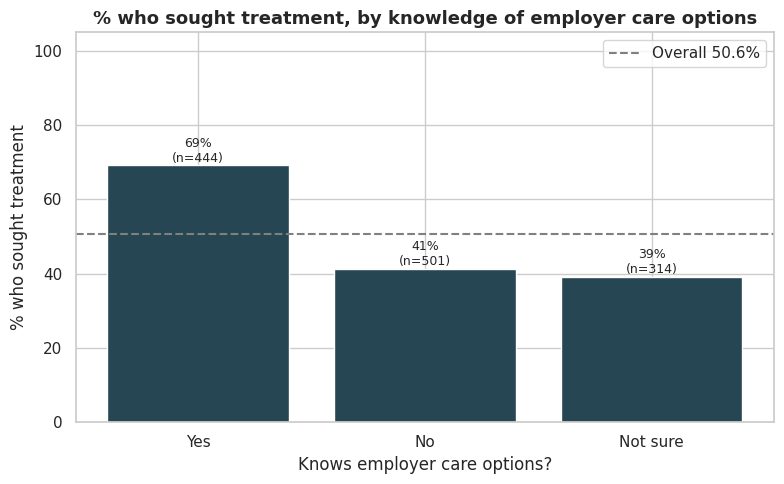

In [25]:
# Chart - 12 visualization code
g = rate_table(df, "care_options", order=["Yes", "No", "Not sure"])
plot_rate(g, "% who sought treatment, by knowledge of employer care options", "Knows employer care options?", figsize=(8, 5), color="#264653")

##### 1. Why did you pick the specific chart?

The same rate-bar format keeps the chart comparable with Chart 11 and isolates the effect of *awareness* rather than the mere existence of benefits.

##### 2. What is/are the insight(s) found from the chart?

Employees who **know** their care options: **69%** sought treatment, versus **41%** (No) and **39%** (Not sure). Awareness has a stronger association (V = 0.27) than benefits alone (V = 0.23).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** awareness campaigns (onboarding sessions, intranet pages, manager briefings) are low-cost and correlate with a +28 point higher treatment rate. **Negative:** 65% of respondents do not know their care options (501 'No' plus 314 'Not sure'); this untapped gap represents unrealised value of existing benefits.

#### Chart - 13 - Work interference vs Treatment (100% stacked bar)

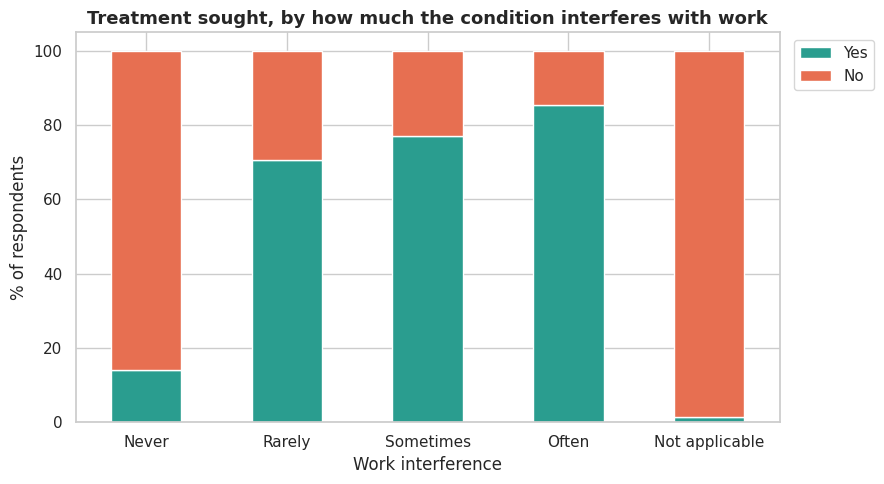

In [26]:
# Chart - 13 visualization code
order = ["Never", "Rarely", "Sometimes", "Often", "Not applicable"]
ct = pd.crosstab(df["work_interfere"], df["treatment"], normalize="index").loc[order, ["Yes", "No"]] * 100
stacked_pct(ct, "Treatment sought, by how much the condition interferes with work", "Work interference", figsize=(9, 5))

##### 1. Why did you pick the specific chart?

A 100% stacked bar compares proportions across ordered intensity levels and shows a monotonic trend clearly.

##### 2. What is/are the insight(s) found from the chart?

Treatment rises steadily with interference: **Never 14% -> Rarely 71% -> Sometimes 77% -> Often 85%**. It is the strongest association in the dataset (V = 0.69). **Caution:** this question is only answered by people who have a condition, so part of the link is built into the survey design and is not a purely behavioural driver.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** as symptoms begin to affect work, most people do seek treatment, so managers who notice performance changes can direct people to support quickly. **Negative growth signal:** 15% of those who say the condition 'Often' interferes with work are still untreated, which is the highest-risk group for burnout and attrition.

#### Chart - 14 - Ease of medical leave vs Treatment (Bar)

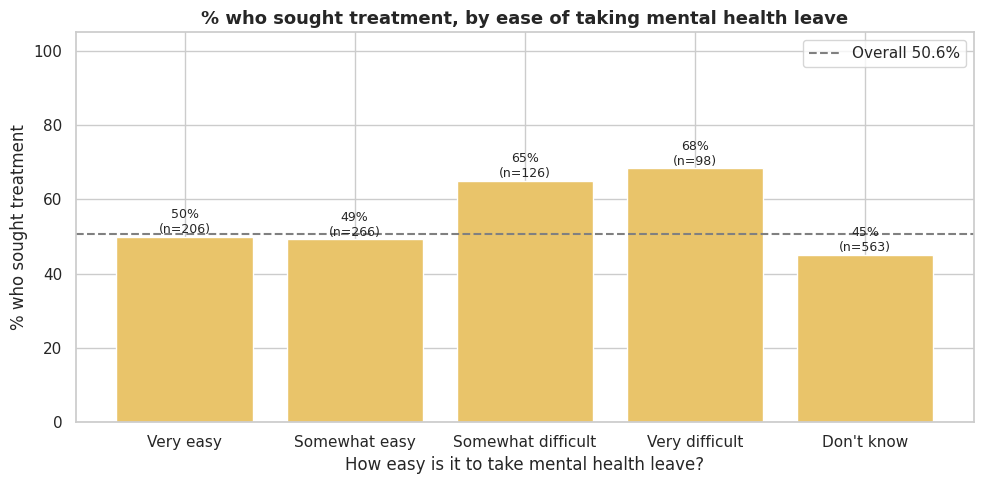

In [27]:
# Chart - 14 visualization code
order = ["Very easy", "Somewhat easy", "Somewhat difficult", "Very difficult", "Don't know"]
g = rate_table(df, "leave", order=order)
plot_rate(g, "% who sought treatment, by ease of taking mental health leave", "How easy is it to take mental health leave?", figsize=(10, 5), color="#e9c46a")

##### 1. Why did you pick the specific chart?

An ordered rate bar shows whether difficulty of taking leave changes treatment behaviour across a natural easy -> difficult scale.

##### 2. What is/are the insight(s) found from the chart?

People who find leave **difficult** report *higher* treatment rates (**Somewhat difficult 65%, Very difficult 68%**) than those who find it easy (49-50%) or don't know (45%). **45% of respondents (563) don't know** how easy leave is.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Negative growth signal:** those needing treatment are exactly the ones facing hard leave policies, which risks burnout, presenteeism and resignations. **Positive:** simplifying and communicating mental health leave (treating it like sick leave) targets a clearly affected group; the large 'Don't know' share means clearer policy documents alone would help.

#### Chart - 15 - Treatment rate by country (Horizontal bar)

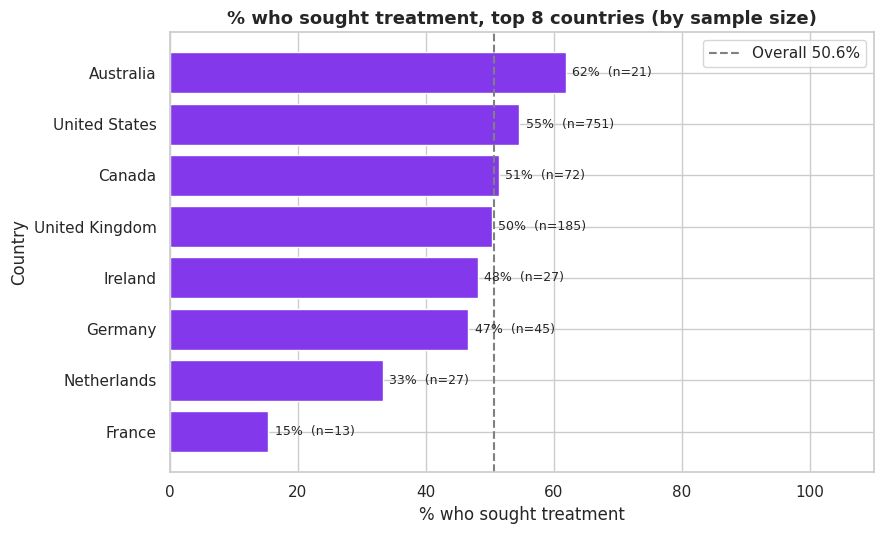

                  n  rate
Country                  
France           13  15.4
Netherlands      27  33.3
Germany          45  46.7
Ireland          27  48.1
United Kingdom  185  50.3
Canada           72  51.4
United States   751  54.6
Australia        21  61.9

Employer benefits = 'Yes' (%):
Country
Germany           11.0
Ireland           11.0
United Kingdom    11.0
France            15.0
Netherlands       15.0
Australia         19.0
Canada            40.0
United States     53.0


In [28]:
# Chart - 15 visualization code
top8 = df["Country"].value_counts().head(8).index.tolist()
g = rate_table(df, "Country", order=top8).sort_values("rate")
plot_rate(g, "% who sought treatment, top 8 countries (by sample size)", "Country", horizontal=True, figsize=(9, 5.5), color="#8338ec")
print(g.round(1).to_string())
print("\nEmployer benefits = 'Yes' (%):")
print((df[df.Country.isin(top8)].groupby("Country")["benefits"].apply(lambda s: (s == "Yes").mean() * 100).round(0)).sort_values().to_string())

##### 1. Why did you pick the specific chart?

Comparing treatment rates by country (not raw counts) addresses the dataset's own question on geographic variation; a sorted horizontal bar handles long labels.

##### 2. What is/are the insight(s) found from the chart?

Among the countries with reasonable samples, the **US (55%, n=751)** is highest, followed by **Canada (51%)**, **UK (50%)**, Ireland (48%) and **Germany (47%)**. The extremes rest on tiny samples: **Australia 62% (n=21)** is highest, while **France 15% (n=13)** and the **Netherlands 33% (n=27)** are lowest. Differences between countries are statistically significant overall (p = 0.017) but modest in size. Employer benefit coverage differs sharply: **US 53% vs UK and Germany 11%**, which likely reflects public healthcare systems in Europe.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** a global employer can tailor programmes to local context (employer-funded benefits in the US, coordination with public systems in Europe). **Caution:** several countries have fewer than 30 respondents, so rankings should be treated as directional; low treatment rates in some countries may signal under-diagnosis or stronger stigma rather than better mental health.

#### Chart - 16 - Treatment rate by US state (n >= 25)

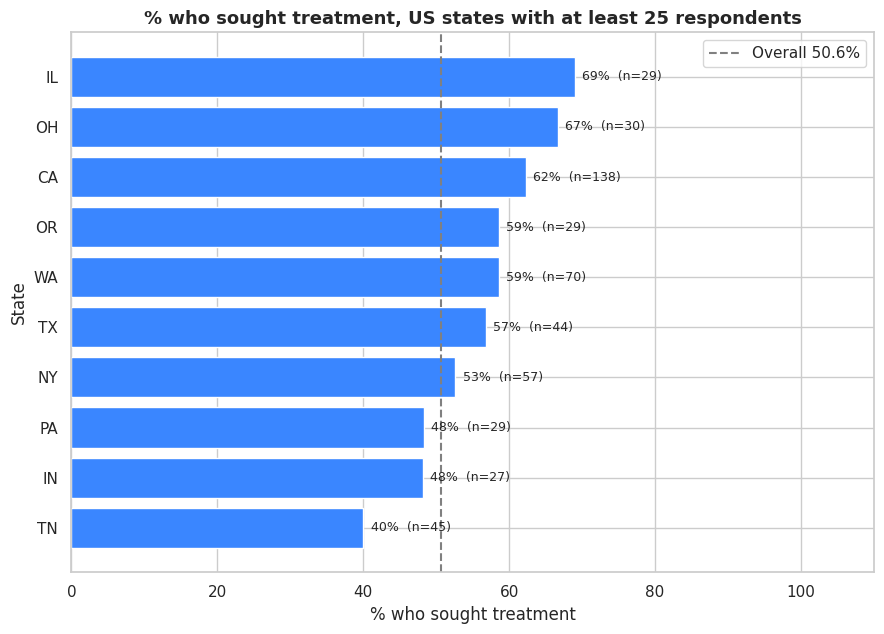

         n  rate
state           
IL      29  69.0
OH      30  66.7
CA     138  62.3
WA      70  58.6


In [29]:
# Chart - 16 visualization code
us = df[df["state"] != "Non-US"]
g = rate_table(us, "state", min_n=25).sort_values("rate")
plot_rate(g, "% who sought treatment, US states with at least 25 respondents", "State", horizontal=True, figsize=(9, 6.5), color="#3a86ff")
print(g.round(1).sort_values("rate", ascending=False).head(4).to_string())

##### 1. Why did you pick the specific chart?

A state-level rate chart addresses the geographic question within the largest market; restricting to n >= 25 avoids misleading extremes from tiny samples.

##### 2. What is/are the insight(s) found from the chart?

Among states with enough data, **Illinois (69%)**, **Ohio (67%)** and **California (62%)** are highest, while **Tennessee (40%)**, Indiana (48%) and Pennsylvania (48%) fall at or below the 50.6% baseline. California is the most reliable figure because it has **138 respondents**; Illinois and Ohio each have about 30 or fewer.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** big tech hubs such as California and Washington show high help-seeking (62% and 59%), indicating more open cultures, so they are good pilot locations for new programmes. **Caution:** per-state samples are small, so any regional targeting should be confirmed with internal data before budget is committed.

#### Chart - 17 - Company size vs Employer benefits (100% stacked bar)

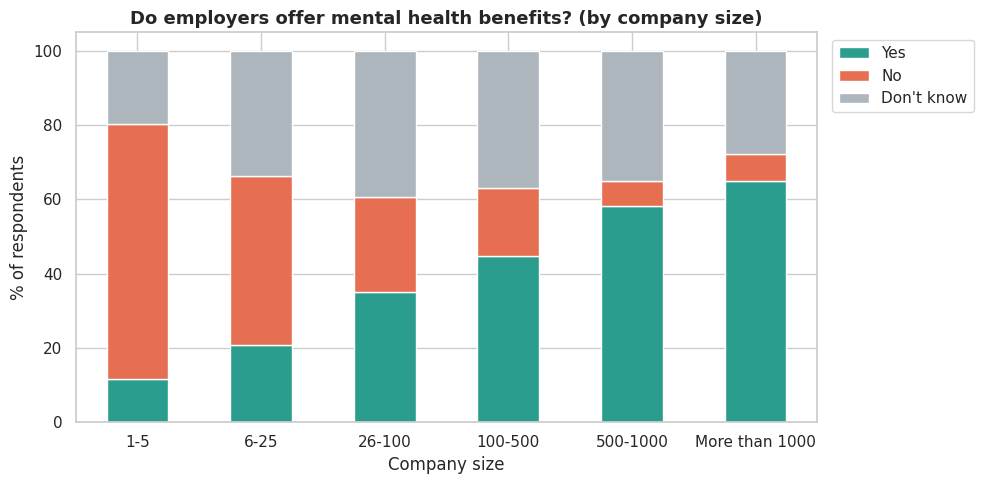

In [30]:
# Chart - 17 visualization code
ct = pd.crosstab(df["no_employees"], df["benefits"], normalize="index").loc[SIZE_ORDER, ["Yes", "No", "Don't know"]] * 100
stacked_pct(ct, "Do employers offer mental health benefits? (by company size)", "Company size", figsize=(10, 5))

##### 1. Why did you pick the specific chart?

A 100% stacked bar shows how the *mix* of answers changes across the ordered company-size categories, which is what a coverage-gap analysis needs.

##### 2. What is/are the insight(s) found from the chart?

Coverage rises steeply with size: **1-5 employees only 12% (69% say No)**, 6-25: 21%, 26-100: 35%, 100-500: 45%, 500-1000: 58% and **1000+: 65%**. Very small companies are the clear support gap.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Negative growth signal:** the ~450 respondents in companies of 25 or fewer have almost no employer support, and are also the most likely to be under-resourced. **Positive:** a huge opportunity for insurers, EAP vendors and industry bodies to offer affordable group plans for small firms; large employers are already doing well and need to work on communication rather than coverage.

#### Chart - 18 - Tech vs non-tech: does the employer take mental health as seriously as physical health? (Grouped bar)

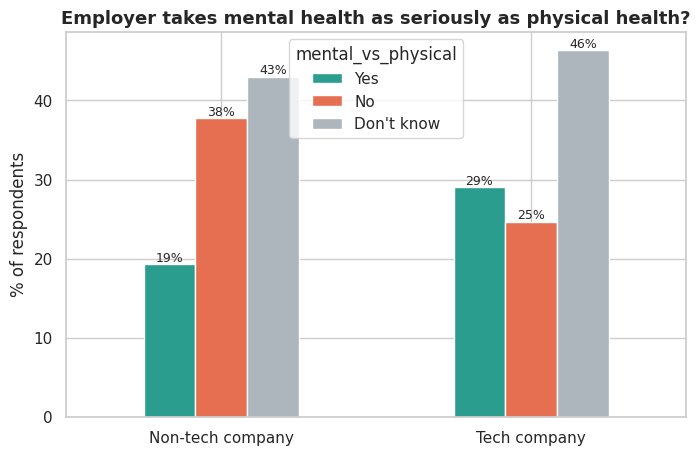

In [31]:
# Chart - 18 visualization code
ct = pd.crosstab(df["tech_company"], df["mental_vs_physical"], normalize="index") * 100
ct = ct[["Yes", "No", "Don't know"]]
ax = ct.rename(index={"Yes": "Tech company", "No": "Non-tech company"}).plot(kind="bar", figsize=(8, 5), color=[PAL[c] for c in ct.columns], rot=0)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.0f%%", fontsize=9)
ax.set_title("Employer takes mental health as seriously as physical health?", fontsize=13, fontweight="bold")
ax.set_ylabel("% of respondents"); ax.set_xlabel("")
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar puts the two employer types side by side on identical answer categories, so differences in perception are easy to compare.

##### 2. What is/are the insight(s) found from the chart?

In **tech companies 29% say Yes, 25% No**, while in **non-tech companies only 19% say Yes and 38% say No**. Yet **only 29% of tech employees agree** and 46% don't know, so a clear majority is either unconvinced or unaware. Interestingly, non-tech employers confirm benefits more often (46% vs 36%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** tech firms are seen as more supportive, which helps as an employer-brand advantage in a competitive hiring market. **Negative growth signal:** fewer than 3 in 10 tech employees believe mental health gets equal weight to physical health, which weakens trust and retention; visible leadership commitment (parity policies, leaders sharing their own experiences) is the lever to fix it.

#### Chart - 19 - Age vs Treatment (Violin + box)

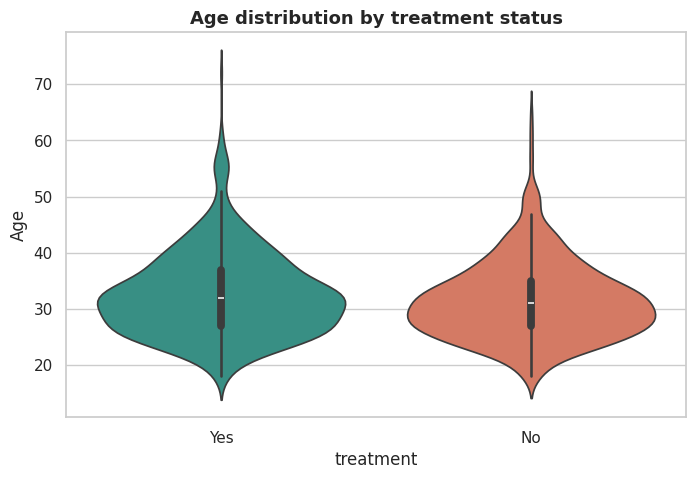

           mean  median  std
treatment                   
No         31.5    31.0  6.9
Yes        32.6    32.0  7.5
Correlation Age vs treatment: 0.073


In [32]:
# Chart - 19 visualization code
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df, x="treatment", y="Age", order=["Yes", "No"], hue="treatment", palette=PAL, inner="box", legend=False, ax=ax)
ax.set_title("Age distribution by treatment status", fontsize=13, fontweight="bold")
plt.show()
print(df.groupby("treatment")["Age"].agg(["mean", "median", "std"]).round(1))
print("Correlation Age vs treatment:", round(df["Age"].corr(df["treatment_bin"]), 3))

##### 1. Why did you pick the specific chart?

A violin plot with an embedded box compares a *numerical* variable across a categorical target and shows the full distribution, not just averages.

##### 2. What is/are the insight(s) found from the chart?

The two distributions almost completely overlap: **median age 32 (treated) vs 31 (not treated)**, correlation only **0.07**. Age alone is a weak predictor of treatment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** mental health support is relevant to all ages, so programmes should not be age-targeted by assumption. **Negative:** because age does not discriminate, companies cannot use age to identify who needs help; they need behavioural or self-reported signals instead.

#### Chart - 20 - Treatment rate by age group (Bar)

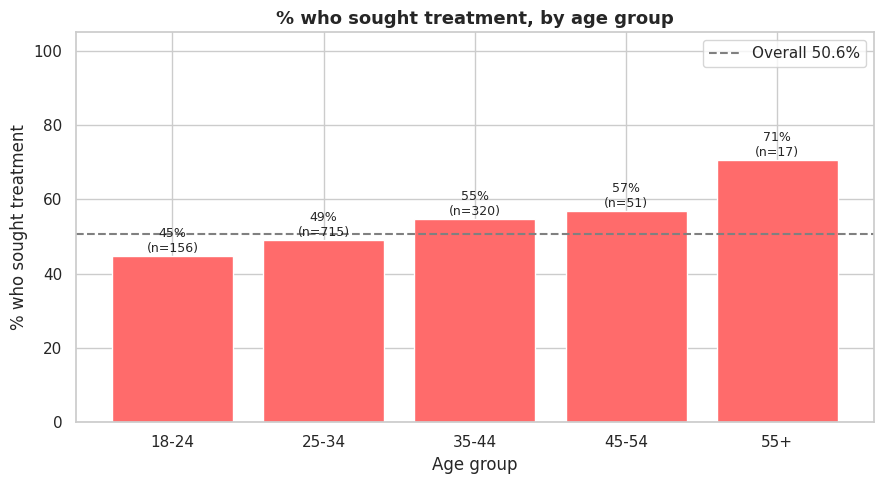

In [33]:
# Chart - 20 visualization code
g = rate_table(df, "age_group", order=["18-24", "25-34", "35-44", "45-54", "55+"])
plot_rate(g, "% who sought treatment, by age group", "Age group", figsize=(9, 5), color="#ff6b6b")

##### 1. Why did you pick the specific chart?

Binning age into life-stage groups turns a weak continuous relationship into a readable trend and shows group sizes, which matter for reliability.

##### 2. What is/are the insight(s) found from the chart?

Treatment rises with age: **18-24: 45% -> 25-34: 49% -> 35-44: 55% -> 45-54: 57% -> 55+: 71%** (only 17 people). The trend is suggestive but not statistically significant (p = 0.079).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the youngest employees (45%) have the most room to increase early help-seeking, so onboarding-stage education has the best long-term payoff. **Negative:** low rates among 18-24 year-olds may reflect stigma or unfamiliarity with the system; without early intervention conditions may progress before treatment starts.

#### Chart - 21 - Perceived consequences: mental vs physical health disclosure (Grouped bar)

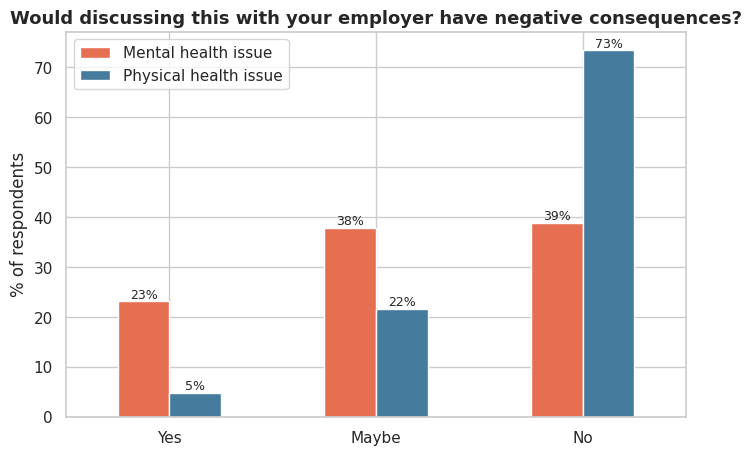

In [34]:
# Chart - 21 visualization code
cons = pd.DataFrame({"Mental health issue": df["mental_health_consequence"].value_counts(normalize=True) * 100,
                     "Physical health issue": df["phys_health_consequence"].value_counts(normalize=True) * 100}).loc[["Yes", "Maybe", "No"]]
ax = cons.plot(kind="bar", figsize=(8, 5), color=["#e76f51", "#457b9d"], rot=0)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.0f%%", fontsize=9)
ax.set_title("Would discussing this with your employer have negative consequences?", fontsize=13, fontweight="bold")
ax.set_ylabel("% of respondents"); ax.set_xlabel("")
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar over the same answer scale makes the *stigma gap* between mental and physical health directly comparable.

##### 2. What is/are the insight(s) found from the chart?

**23% expect negative consequences for a mental health disclosure versus only 5% for a physical one**, and another 38% say 'Maybe'. Only **39%** feel safe (say No) for mental health versus **74%** for physical health.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Negative growth signal:** this is the core stigma finding. If six in ten employees are unsure or fear consequences, problems stay hidden until they become crises, which raises attrition and sick-leave costs. **Positive:** it gives HR a measurable KPI (e.g. re-run this question yearly) and a clear message for anti-stigma training.

#### Chart - 22 - Willingness to disclose: who and when (Bar)

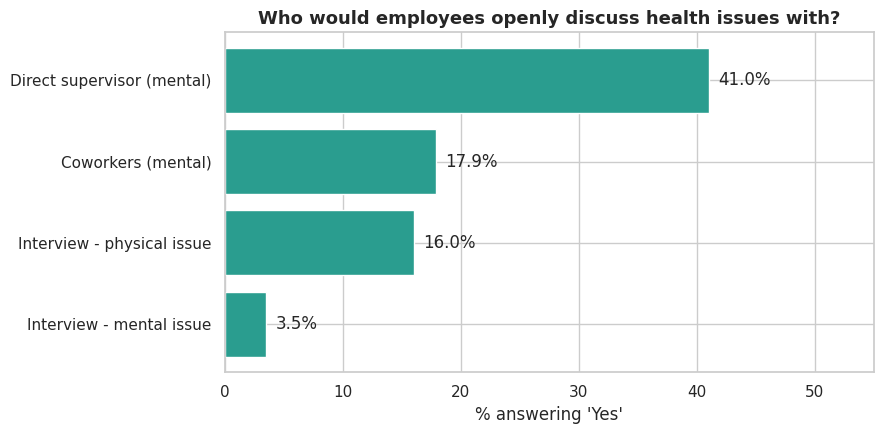

Coworkers 'Some of them': 61.5 %


In [35]:
# Chart - 22 visualization code
disc = pd.Series({"Direct supervisor (mental)": (df["supervisor"] == "Yes").mean() * 100,
                  "Coworkers (mental)": (df["coworkers"] == "Yes").mean() * 100,
                  "Interview - physical issue": (df["phys_health_interview"] == "Yes").mean() * 100,
                  "Interview - mental issue": (df["mental_health_interview"] == "Yes").mean() * 100}).sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(disc.index, disc.values, color="#2a9d8f")
for i, v in enumerate(disc.values):
    ax.text(v + 0.8, i, f"{v:.1f}%", va="center")
ax.set_xlim(0, 55); ax.set_xlabel("% answering 'Yes'")
ax.set_title("Who would employees openly discuss health issues with?", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print("Coworkers 'Some of them':", round((df["coworkers"] == "Some of them").mean() * 100, 1), "%")

##### 1. Why did you pick the specific chart?

A sorted horizontal bar ranks the disclosure scenarios from most to least comfortable, which shows where trust breaks down.

##### 2. What is/are the insight(s) found from the chart?

**41% would tell their supervisor**, **only 18% would tell all coworkers** (62% would tell 'some of them'), and in interviews just **3.5% would raise a mental health issue versus 16% for a physical one**. Employees trust managers more than peers, and almost never volunteer mental health to prospective employers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the supervisor is the most trusted channel, so manager training (how to respond, refer and protect confidentiality) is the highest-leverage investment. **Negative growth signal:** candidates hide mental health during hiring, so employers lose the chance to offer accommodations early; inclusive hiring statements can reduce that fear.

#### Chart - 23 - Ranking predictors of treatment: Cramer's V with chi-square significance (Bar)

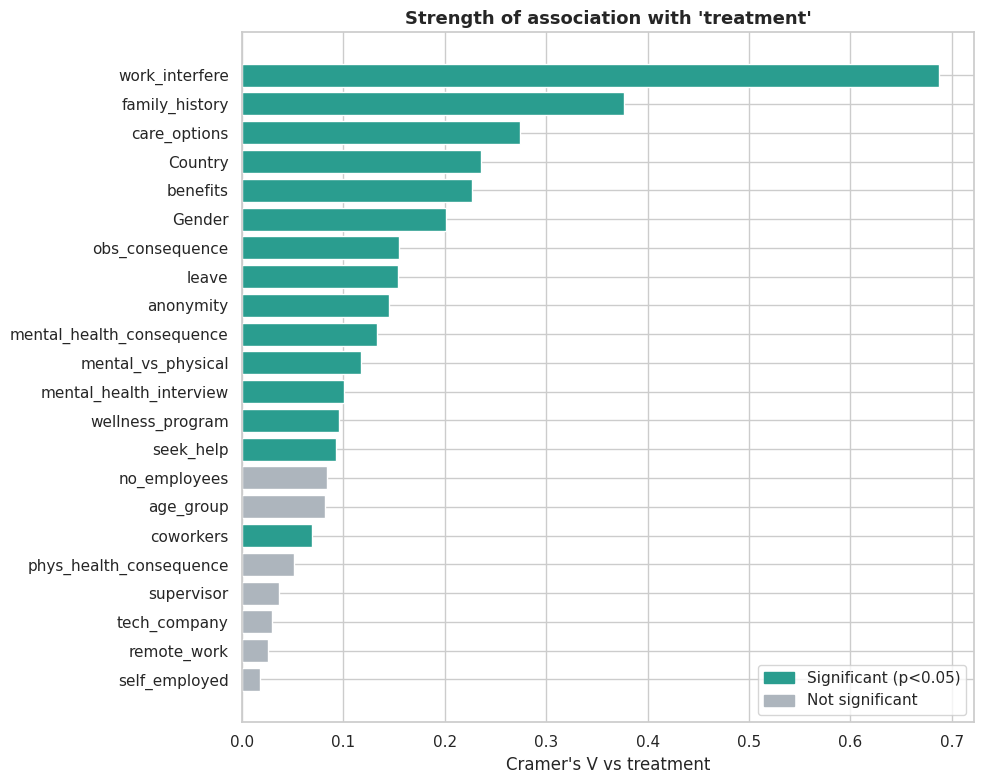

,variable,cramers_v,p_value,significant
0,work_interfere,0.6874,0.0000,Significant (p<0.05)
1,family_history,0.3763,0.0000,Significant (p<0.05)
2,care_options,0.2743,0.0000,Significant (p<0.05)
3,Country,0.2355,0.0171,Significant (p<0.05)
4,benefits,0.2269,0.0000,Significant (p<0.05)
5,Gender,0.2014,0.0000,Significant (p<0.05)
6,obs_consequence,0.1547,0.0000,Significant (p<0.05)
7,leave,0.1542,0.0000,Significant (p<0.05)
8,anonymity,0.1449,0.0000,Significant (p<0.05)
9,mental_health_consequence,0.1332,0.0000,Significant (p<0.05)


In [36]:
# Chart - 23 visualization code
def cramers_v(x, y):
    """Cramer's V (0 = no association, 1 = perfect) and chi-square p-value for two categorical series."""
    ct = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(ct)
    return np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1))), p

TESTS = ["work_interfere", "family_history", "care_options", "Country", "benefits", "Gender", "obs_consequence", "leave", "anonymity",
         "mental_health_consequence", "mental_vs_physical", "mental_health_interview", "wellness_program", "seek_help", "no_employees",
         "age_group", "coworkers", "phys_health_consequence", "supervisor", "tech_company", "remote_work", "self_employed"]
res = pd.DataFrame([(c, *cramers_v(df[c], df["treatment"])) for c in TESTS], columns=["variable", "cramers_v", "p_value"]).sort_values("cramers_v")
res["significant"] = np.where(res["p_value"] < 0.05, "Significant (p<0.05)", "Not significant")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(res["variable"], res["cramers_v"], color=res["significant"].map({"Significant (p<0.05)": "#2a9d8f", "Not significant": "#adb5bd"}))
ax.set_xlabel("Cramer's V vs treatment"); ax.set_title("Strength of association with 'treatment'", fontsize=13, fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2a9d8f", label="Significant (p<0.05)"), Patch(color="#adb5bd", label="Not significant")], loc="lower right")
plt.tight_layout(); plt.show()
res.sort_values("cramers_v", ascending=False).round(4).reset_index(drop=True)

##### 1. Why did you pick the specific chart?

Every variable here is categorical, so Cramer's V (built on the chi-square test) is the correct measure of association strength; ranking them answers the dataset's own question about the strongest predictors.

##### 2. What is/are the insight(s) found from the chart?

**work_interfere (0.69)** and **family_history (0.38)** dominate, followed by **care_options (0.27)**, Country (0.24), **benefits (0.23)** and **Gender (0.20)**. Company size, age group, being tech / remote / self-employed, supervisor comfort and physical-consequence fear are **not statistically significant** (p > 0.05).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the ranking shows where to invest: awareness of care options and benefits are *actionable* levers, while demographics like remote work or tech company type do not matter, so blanket assumptions such as 'remote staff need more support' are not supported by the data. **Caution:** association is not causation, and work_interfere is partly structural (see Chart 13).

### **C. Multivariate Analysis (Charts 24-26)**

#### Chart - 24 - Correlation Heatmap

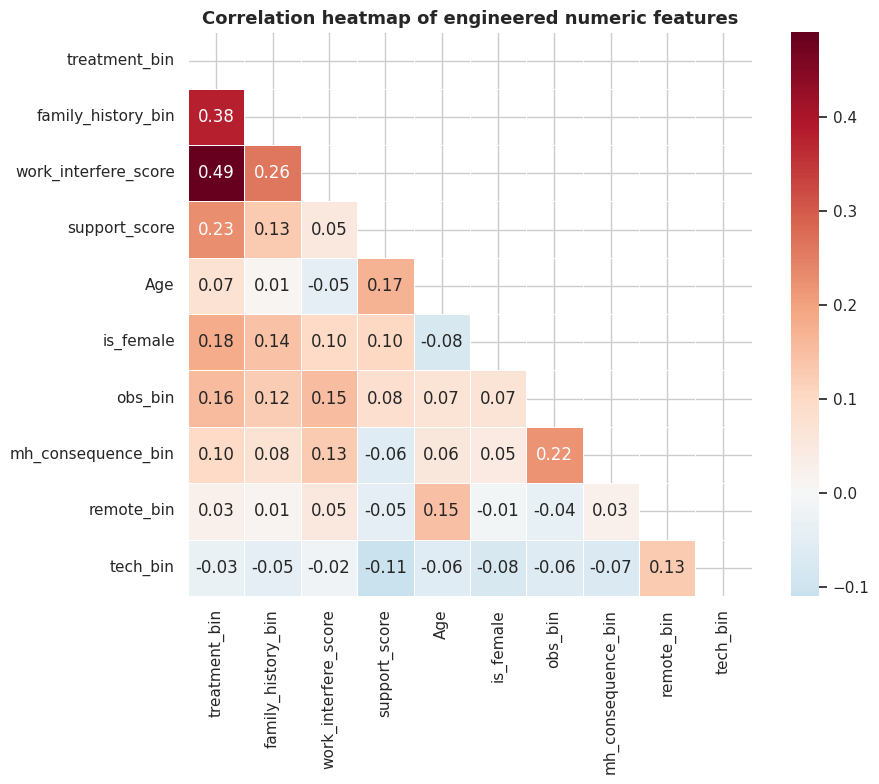

work_interfere_score    0.49
family_history_bin      0.38
support_score           0.23
is_female               0.18
obs_bin                 0.16
mh_consequence_bin      0.10
Age                     0.07
remote_bin              0.03
tech_bin               -0.03


In [37]:
# Chart - 24 visualization code
num_cols = ["treatment_bin", "family_history_bin", "work_interfere_score", "support_score", "Age",
            "is_female", "obs_bin", "mh_consequence_bin", "remote_bin", "tech_bin"]
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))            # hide the duplicate upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5, square=True)
plt.title("Correlation heatmap of engineered numeric features", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print(corr["treatment_bin"].drop("treatment_bin").sort_values(ascending=False).round(2).to_string())

##### 1. Why did you pick the specific chart?

A correlation heatmap summarises the pairwise linear relationships between all engineered numeric and binary features in one picture, and reveals redundancy between predictors.

##### 2. What is/are the insight(s) found from the chart?

Correlation with treatment: **work_interfere_score 0.49**, **family_history 0.38**, **support_score 0.23**, **female 0.18**, observed consequences 0.16, fear of consequences 0.10, age 0.07, and remote / tech about 0. Also notable: **support_score correlates with age (0.17)** and negatively with **tech company (-0.11)**, meaning tech firms confirm *fewer* support features than non-tech firms.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** no pair of predictors is highly collinear (all below 0.5), so all could be used together in a future predictive model. **Negative growth signal:** the negative link between tech-company status and confirmed support suggests the very industry with the highest stress is under-delivering on structured support.

#### Chart - 25 - Pair Plot (Age, work interference, support score by treatment)

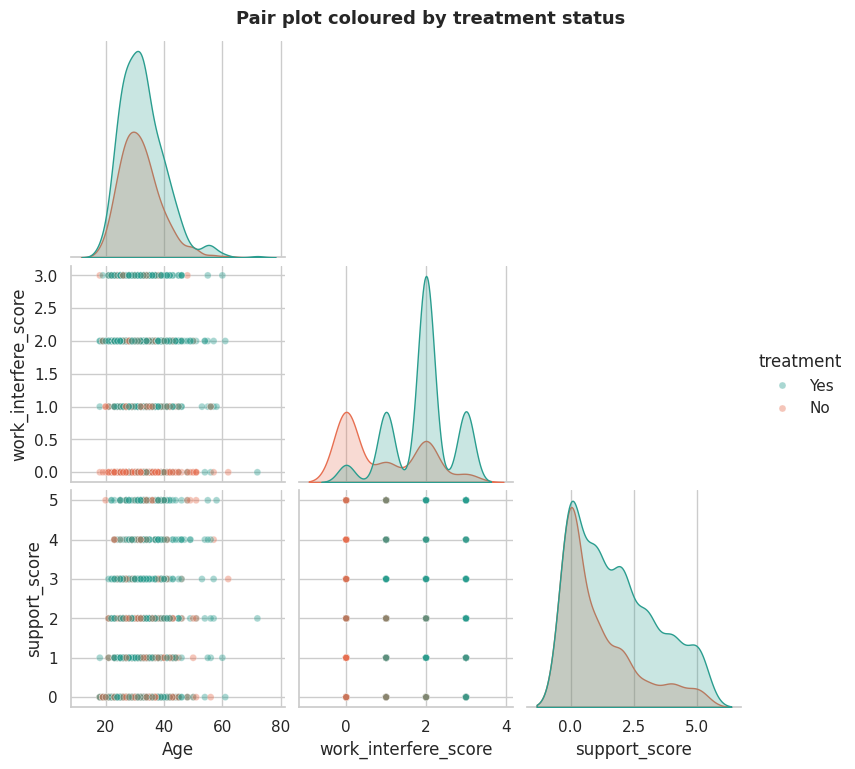

           work_interfere_score  support_score    Age
treatment                                            
No                         0.91           1.05  31.53
Yes                        1.91           1.76  32.59


In [38]:
# Chart - 25 visualization code
pp_df = df.dropna(subset=["work_interfere_score"])[["Age", "work_interfere_score", "support_score", "treatment"]]
g = sns.pairplot(pp_df, hue="treatment", palette=PAL, diag_kind="kde", corner=True, plot_kws={"alpha": 0.4, "s": 25})
g.fig.suptitle("Pair plot coloured by treatment status", y=1.02, fontsize=13, fontweight="bold")
plt.show()
print(df.groupby("treatment")[["work_interfere_score", "support_score", "Age"]].mean().round(2))

##### 1. Why did you pick the specific chart?

A pair plot shows each feature's distribution and every pairwise scatter at once, coloured by the target, so class separation can be judged visually before modelling.

##### 2. What is/are the insight(s) found from the chart?

Treated respondents are clearly separated on **work interference (mean 1.91 vs 0.91)** and **support score (1.76 vs 1.05)**, whereas **age overlaps almost completely (32.6 vs 31.5)**. **53% of untreated respondents confirm no employer support feature at all, versus 30% of treated respondents.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the separation on support score means employees who *know* their support features are much more likely to be in treatment, which supports investment in awareness. **Negative:** age offers no separation, so age-based targeting would waste budget.

#### Chart - 26 - Multivariate heatmaps: treatment rate by Family history x Benefits and Gender x Age group

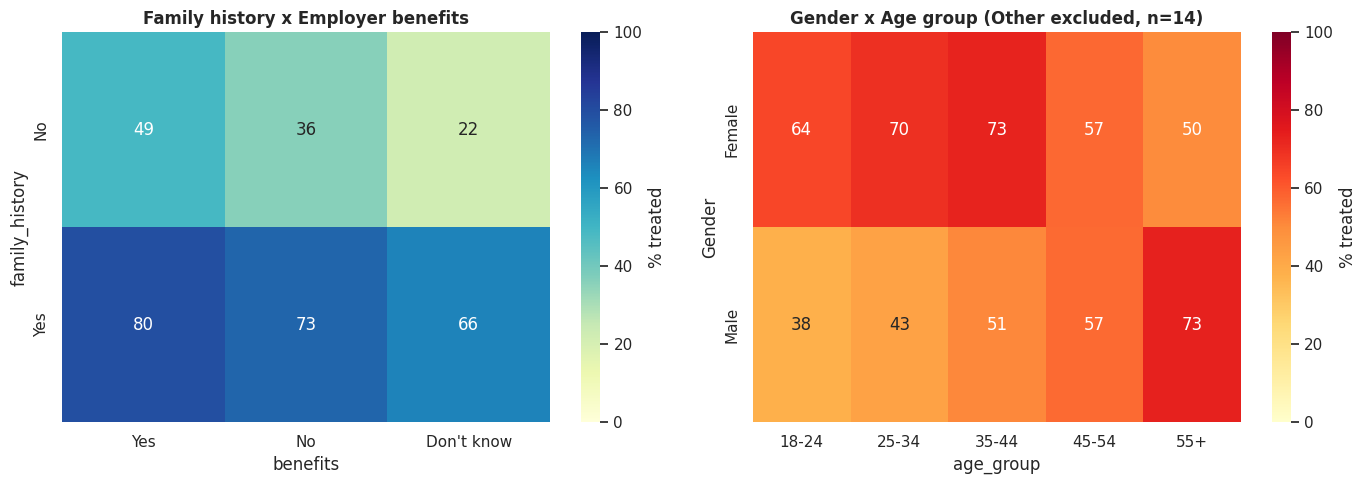

In [39]:
# Chart - 26 visualization code
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
p1 = df.pivot_table(index="family_history", columns="benefits", values="treatment_bin", aggfunc="mean")[["Yes", "No", "Don't know"]] * 100
sns.heatmap(p1, annot=True, fmt=".0f", cmap="YlGnBu", vmin=0, vmax=100, ax=axes[0], cbar_kws={"label": "% treated"})
axes[0].set_title("Family history x Employer benefits", fontweight="bold")

p2 = df[df["Gender"] != "Other"].pivot_table(index="Gender", columns="age_group", values="treatment_bin", aggfunc="mean", observed=True) * 100
sns.heatmap(p2, annot=True, fmt=".0f", cmap="YlOrRd", vmin=0, vmax=100, ax=axes[1], cbar_kws={"label": "% treated"})
axes[1].set_title("Gender x Age group (Other excluded, n=14)", fontweight="bold")
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?

Pivot heatmaps show how the *combination* of two factors affects treatment rate, which reveals interaction effects that single-variable charts hide.

##### 2. What is/are the insight(s) found from the chart?

**Family history and benefits both matter, and they add up:** treatment ranges from **22%** (no family history, doesn't know benefits) to **80%** (family history + benefits). Even with family history, employees unaware of their benefits have only a 66% rate. **Gender x age:** women sit between 64% and 73% for ages 18-44 (peaking at 73% for 35-44), whereas men rise from **38% (18-24)** to **43% (25-34)** and **51% (35-44)**; the 45+ cells (and the 55+ male figure of 73%) rest on very few people.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** high-risk employees (family history) with clear benefits are well served, and the marked age climb among men shows that early-career men are the biggest untapped group, so a male-focused, stigma-reducing campaign for under-35s is a clear opportunity. **Negative growth signal:** employees with no family history who don't know their benefits have only a 22% rate; silent cases are probably concentrated here, which is exactly where an awareness campaign should aim.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?

Based on the evidence in 26 charts and statistical tests, I recommend:

1. **Fix communication before adding budget.** 65% of employees don't know their care options, 65% don't know if anonymity is protected and 45% don't know how mental health leave works. Employees who know their care options have a **69% vs ~40%** treatment rate. Launch an onboarding module, a one-page benefits guide and a yearly reminder campaign (Charts 7, 12, 14).
2. **Guarantee and publicise anonymity.** Use an external EAP provider with confidential access so that employees are sure that using it is safe (Charts 7, 21).
3. **Train managers first.** Supervisors are the most trusted channel (41% would disclose to them vs 18% to all coworkers). Short training on listening, referring and protecting confidentiality is the highest-leverage step (Chart 22).
4. **Close the small-company coverage gap.** Only 12% of firms with 1-5 employees and 21% of firms with 6-25 employees offer benefits. Partner with insurers, industry bodies or vendors for affordable group plans (Chart 17).
5. **Treat mental health leave like sick leave.** Employees who find leave difficult are the ones most likely to be in treatment (65-68%). Simplify the process and state the policy clearly (Chart 14).
6. **Reduce stigma with visible leadership.** 23% fear negative consequences for mental health vs 5% for physical; fewer than 3 in 10 tech employees believe mental health is taken as seriously as physical health. Leadership storytelling, parity policies and an annual pulse survey (using these same questions as KPIs) will show progress (Charts 18, 21).
7. **Target the right groups.** Use outreach for employees with a family history (74% treated), for early-career men under 35 (lowest rates among the big groups) and for staff who say the condition often interferes with work. Do **not** target by remote-work or tech status, or by age alone, as they show no meaningful effect (Charts 9, 10, 23, 26).
8. **Measure and iterate.** Track treatment-utilisation, benefit awareness and disclosure comfort every 6-12 months.

**Data limitations:** the survey is a 2014 self-selected sample (49% of responses came on launch day), 79% male and 60% US-based, so absolute percentages should be validated against the company's own data. Association is not causation.

# **Conclusion**

The analysis of 1,259 respondents shows that **mental health need in tech is high (51% have sought treatment) but workplace support is fragmented, poorly communicated and undermined by stigma.** The strongest signals are family history (74% vs 36%), work interference, and **awareness of care options (69% vs ~40%)**; company size, remote work, tech-company status and self-employment show no significant relationship with treatment.

Employees fear consequences far more for mental health than for physical health (23% vs 5%), rarely disclose it in interviews (3.5% vs 16%) and trust supervisors far more than coworkers. Small companies provide almost no support (12% at 1-5 employees), while employees in large firms have benefits they often do not know about.

For the client, the most valuable and cheapest actions are **communicating existing benefits, guaranteeing anonymity, training managers, making leave simple and closing the small-firm gap.** Results should be read as directional because of self-selection and demographic skew, and the strong link between work interference and treatment is partly a survey-design effect. A natural next step is a predictive model (e.g. logistic regression / random forest) using the features identified here, plus a comparison with the 2016 survey to test whether attitudes have changed.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***